In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score ,recall_score, f1_score

In [3]:
data = load_breast_cancer()

x= pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    (data.target == 0).astype(int),
    name = "malignant"
)

print(y.value_counts())
print("feature shape = ",x.shape)
print("target shape = ",y.shape)
print("class names: ",data.target_names)

malignant
0    357
1    212
Name: count, dtype: int64
feature shape =  (569, 30)
target shape =  (569,)
class names:  ['malignant' 'benign']


In [4]:
class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({
    "class": data.target_names,
    "count": class_counts.values,
    "Probability": (class_counts.values)/len(y)
})

print(class_distribution)

       class  count  Probability
0  malignant    357     0.627417
1     benign    212     0.372583


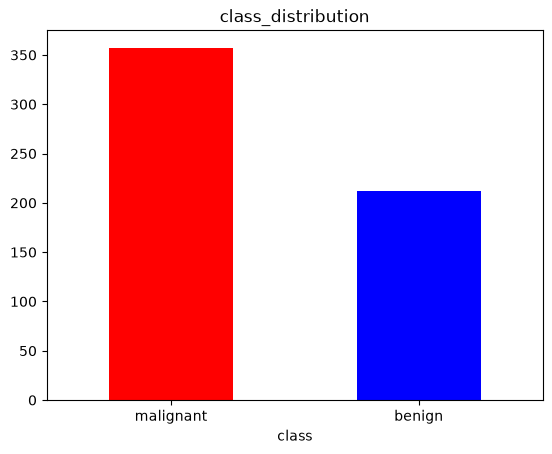

In [26]:
class_distribution.plot(
    x= "class",
    y="count",
    kind = "bar",
    legend = False,
    color = ['red','blue']
)

plt.title("class_distribution")

plt.xticks(rotation=0)
plt.show()

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state=42,stratify=y)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

print("Training_counts: ")
print(y_train.value_counts(normalize=True).sort_index())
print("Testing_counts: ")
print(y_test.value_counts(normalize=True).sort_index())

(455, 30)
(114, 30)
(455,)
(114,)
Training_counts: 
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64
Testing_counts: 
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [14]:
model =make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [15]:
probabilties =model.predict_proba(x_test)
print(probabilties[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [16]:
print(probabilties[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


In [19]:
results = pd.DataFrame({
    "actual_class": y_test.values,
    "P_malignant" : probabilties[:,0],
    "P_benign" : probabilties[:,1]
})

results.head(10)

,actual_class,P_malignant,P_benign
0,0,9.996354e-01,0.000365
1,1,1.074660e-08,1.000000
2,0,9.574321e-01,0.042568
3,1,4.238127e-01,0.576187
4,0,4.908445e-01,0.509155
5,0,9.993840e-01,0.000616
6,1,2.384659e-01,0.761534
7,0,9.989878e-01,0.001012
8,0,9.994313e-01,0.000569
9,0,9.892324e-01,0.010768


In [21]:
threshold = 0.5 

results["Predicted_malignant"] = (
    results["P_malignant"]>= threshold
).astype(int)
results["Predicted_label"] = (
    results["Predicted_malignant"].map({
        0:"malignant",
        1:"benign"
    })
)

print(
    results[["actual_class","P_malignant","Predicted_label"]].head(10)
)

   actual_class   P_malignant Predicted_label
0             0  9.996354e-01          benign
1             1  1.074660e-08       malignant
2             0  9.574321e-01          benign
3             1  4.238127e-01       malignant
4             0  4.908445e-01       malignant
5             0  9.993840e-01          benign
6             1  2.384659e-01       malignant
7             0  9.989878e-01          benign
8             0  9.994313e-01          benign
9             0  9.892324e-01          benign


In [25]:
for threshold in [0.3,0.5,0.7]:
    predictions = (
        results["P_malignant"]>=threshold
    ).astype(int)
    
    print(
        f"threshold = {threshold}: "
        f"Predicted_malignant_class = {predictions.sum()}"
    )
    print("confusion_matrix:")
    print(confusion_matrix(y_test,predictions))

threshold = 0.3: Predicted_malignant_class = 76
confusion_matrix:
[[ 0 72]
 [38  4]]
threshold = 0.5: Predicted_malignant_class = 74
confusion_matrix:
[[ 1 71]
 [39  3]]
threshold = 0.7: Predicted_malignant_class = 72
confusion_matrix:
[[ 1 71]
 [41  1]]


In [29]:
y_pred = model.predict(x_test)

print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print("precision_score: ", precision_score(y_test,y_pred))
print("recall_score: ", recall_score(y_test,y_pred))
print("f1 score: ", f1_score(y_test,y_pred))

Accuracy Score:  0.9649122807017544
precision_score:  0.975
recall_score:  0.9285714285714286
f1 score:  0.9512195121951219


In [34]:
from sklearn.metrics import confusion_matrix

metric_results = []
for threshold in [0.1,0.3,0.5,0.7,0.9]:
    y_pred_threshold=(probabilties[:,1]>=threshold).astype(int)

    tn,fp,fn,tp =confusion_matrix(y_test,y_pred_threshold,labels=[0,1]).ravel()

    accuracy = (tp+tn)/(tp+tn+fp+fn)
    precision =  tp / (tp+fp) if(tp+fp)>0 else 0
    sensitivity = tp /(tp+fn) if (tp+fn)>0 else 0
    specificity = tn / (tn+fp) if (tn+fp)>0 else 0

    f1_score =(
        2*precision * sensitivity /(precision + sensitivity) if precision+sensitivity >0 else 0
    )

    metric_results.append({
        "Threshold": threshold,
        "TN":tn,
        "TP":tp,
        "FN": fn,
        "FP": fp,
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1score": f1_score  
    })

threshold_metrics = pd.DataFrame(metric_results)

threshold_metrics.head(5)

,Threshold,TN,TP,FN,FP,accuracy,precision,sensitivity,specificity,f1score
0,0.1,67,41,1,5,0.947368,0.891304,0.976190,0.930556,0.931818
1,0.3,71,41,1,1,0.982456,0.976190,0.976190,0.986111,0.976190
2,0.5,71,39,3,1,0.964912,0.975000,0.928571,0.986111,0.951220
3,0.7,72,38,4,0,0.964912,1.000000,0.904762,1.000000,0.950000
4,0.9,72,33,9,0,0.921053,1.000000,0.785714,1.000000,0.880000


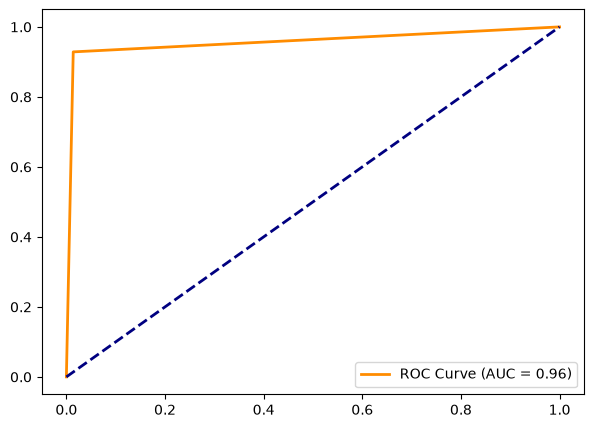

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

auc_score = roc_auc_score(y_test,y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.legend()